In [1]:
%load_ext autoreload
%autoreload 2

# Importing the modules
import os
os.environ['OMP_NUM_THREADS'] = '8' # Force the system to allocate 8 threads to OpenMP
os.environ['NGS_NUM_THREADS'] = '8' # Force NGSolve's internal task manager to use 8 threads
import ngsolve as ngs
ngs.SetNumThreads(8)

In [1]:
import config_dict as cfg                    # config = physical & simulation parameters 
from solver_2DHcurl_1DH1 import *            # solver = mesh build, physics import and FEM method + pmls initialization
# from solver_2DHcurl_1DH1_Copie import *
import PP_Run_and_Save as pp_run     # post process run and save = run scan function and save data in H5 files
import PP_Plot_and_Load as pp_plot   # post process load and plot = recover the sim data from H5 files and plot graphs "instantly"

import Antenna_Desc_n_Plot as antenna

geom_mode = "2D" # "1D" or "2D" 
box_medium = "PLASMA" # "VACUUM" or "PLASMA" 

antenna_grill = not None
if antenna_grill != None:
    antenna_grill = antenna.AntennaGrill(b_active=0.009, d_septa=0.001, d_gap=0.002, Lx_wg_active=0.08, Lx_wg_passive=0.02, b_passive=0.009)
    num_active=6
    is_PAM=False
    antenna_grill.add_module(num_active, is_PAM, delta_phi_deg=-150, amplitude=10)
    antenna_grill.add_module(num_active, is_PAM, delta_phi_deg=-150, amplitude=10)
    antenna_grill.add_module(num_active, is_PAM, delta_phi_deg=-150, amplitude=10)

    instructions = antenna_grill.generate_mesh_instructions()
    #antenna.plot_antenna_blueprint(instructions)

solver = LHCouplingSolver_2DHcurl_1DH1(cfg.__dict__, geom_mode, box_medium, antenna_grill)

Waveguide Medium set to: VACUUM


In [3]:
# %%capture
mesh = solver.build_mesh_with_PMLs()
solver.build_physics_Stix_B_field()

GF_E_field, Gamma_R, Gamma_T, diag_data = solver.solve_helmholtz_2DHcurl_1DH1_with_pml(mesh, geom_mode, box_medium)

==== 
Lx_plasma: 5.00e-02m,   Lx_pml: 6.51e-03m,    Lx_tot: 5.65e-02m
Lx_wg = 3.00e-02m
Lz_antenna: 2.19e-01m, Lz_wall: 2.00e-02m
Lz_plasma: 2.19e-01m, Lz_pml: 1.21e-01m, Lz_tot: 5.02e-01m
==== 
n_∥: 2.0+0.0j,   λ_∥: 4.05e-02m 
n_⟂⁺ (edge): 2.41+0.00j, n_⟂⁺ (core): 12.45
λ_⟂⁺ (core): 6.51e-03m 
n_⟂-:0.00+1.73j, λ_⟂⁻: 4.68e-02m
[MESH GENERATED !]
Lx_wg: 3.00e-02m, wg_medium: VACUUM
Waveguide medium is not PLASMA, wg_is_plasma set to 0.0
==== 
#DoFs = 4309381
len(instruction): 43
n_perp_vac_port: 1.00+0.00j
==== 
w_size_R: 5.0454e-02m,    w_size_T: 6.0769e-02m
Gamma_R (SWR) = 9.986e-01
Gamma_T (SWR) = 9.241e-01

--- Poynting Flux & Energy Conservation ---
Net Power Injected (Antenna): -3.8551e-03 W/m
Net Power Exiting to PMLs:    6.2372e-03 W/m
Plasma Bulk Conservation Error: 2.62e+02 %


In [4]:
# solver.plot_radial_density_profile()

In [4]:
# Create the Run_XXX_XXX file in Simulation_Results folder
# run_folder = /Simulation_Results/Run_XXX
run_folder_path = pp_run.setup_output_directory("Simulation_Results", save_data=True)

# Total Run_XXX folder path to Remi's shared zone (cea intra) 
# run_folder_tot_path = "/home/remi/Perso/Stage/M2_IRFM/Codes/2D_Complete_Version/" + run_folder_path
run_folder_tot_path = '/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/' + run_folder_path
print(f'sim_target_folder: {run_folder_tot_path}')



[SYSTEM] Output directory created: Simulation_Results/Run_20260804_093736
sim_target_folder: /Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Simulation_Results/Run_20260804_093736


In [5]:
E_map2D_h5_filepath = pp_run.run_2D_wave_map(mesh, GF_E_field, cfg, run_folder_tot_path, geom_mode, box_medium, antenna_grill, diag_data)

Lz_wall = cfg.DOMAIN.get('Lz_wall', 0.02)

# pp_plot.plot_2D_wave_map(E_map2D_h5_filepath, run_folder_tot_path, geom_mode, component='E_norm', value_type='real',
#                         antenna_grill=antenna_grill, Lz_wall=Lz_wall, plot_poynting=False, show_windows_R=False, show_windows_T=False, Poynting_box=False)

--- Extracting 2D Wave Map ---
Lz_plasma_src: 0.219, Lz_wall: 0.020, Lz_pml: 0.121, Lz_tot: 0.502
Bornes géométriques fixées
  --> Pure Multithreaded C++ vectorized interpolation...
Waveguide Medium set to: VACUUM
PP_run_n_save: n_para: 2.0+0.0j, n_perp_p: 2.41e+00+0.00e+00j, n_perp_m: 0.00e+00+1.73e+00j
Params recovered
h5_path = /Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Simulation_Results/Run_20260804_093736/Wave_Map_2D.h5
type(h5_path) = <class 'str'>
oui

PRINT H5 METADATA:
 Lx_plasma: 5.00e-02
 Lx_pml: 6.51e-03
 Lx_tot: 5.65e-02
 Lz_plasma: 2.19e-01
 Lz_pml: 1.21e-01
 Lz_tot: 5.02e-01
 P_in_net: -3.86e-03
 P_out_Radial: 1.38e-05
 P_out_Toroidal: 6.22e-03
 eta_pred_R: 2.49e-01
 eta_pred_T: 4.29e-17
 eta_sim_R: 9.99e-01
 eta_sim_T: 9.24e-01
 k_para: (-155.09253162442445+0j)
 k_perp_p: (-186.8005952617502+0j)
 lambda_perp_real: 3.36e-02
 n_para_imag: 0.00e+00
 n_para_real: 2.00e+00
 peak_x_T: 5.00e-04
 peak_z_R: 2.53e-01
 power_error_plasma: 2.62e+00
 window_size_radia

In [7]:
# pp_plot.plot_1D_radial_slice_with_theory(
#     h5_filepath=E_map2D_h5_filepath, 
#     cfg=cfg.__dict__, 
#     component='Ez', 
#     z_eval=0.20)  # None for exact center

/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/PP_Plot_and_Load.py:286: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12)


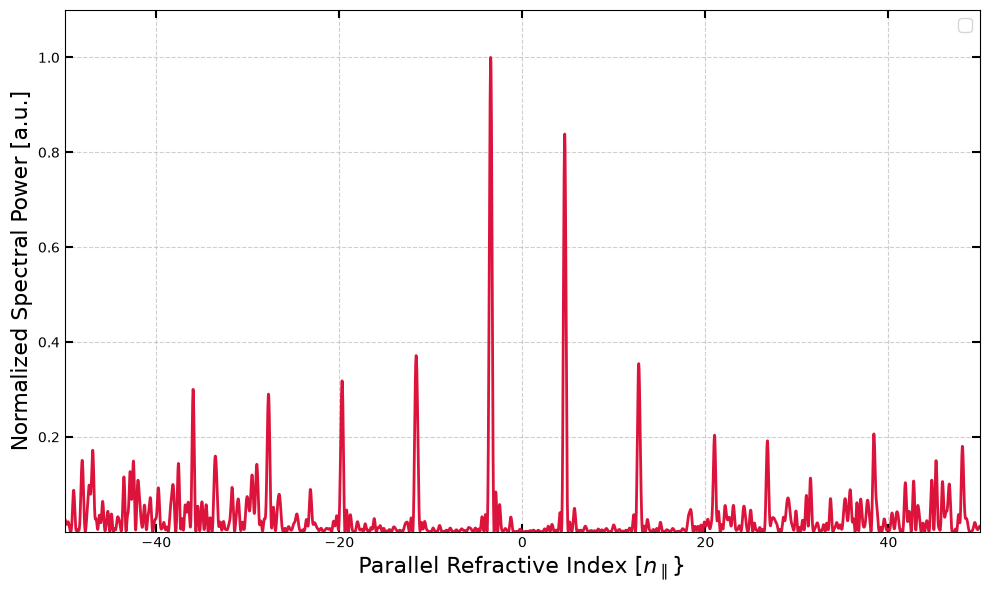

In [ ]:
# Test n_para spectrum
# n_para_array, power_spectrum = pp_plot.plot_n_para_spectrum(mesh, GF_E_field, cfg, geom_mode, run_folder_tot_path, x_eval=0.01)


In [9]:
# wg_s_params = solver.compute_waveguide_S_parameters()


In [10]:
# ===========================
aperture_fields = solver.extract_tangential_aperture_fields(x_target=0.0)
# # ===========================

import matplotlib.pyplot as plt
import numpy as np

def plot_aperture_fields(field_data, x_target, save_dir=None):
    """
    Plots the complex electric field components along the toroidal (z) direction.
    Ideal for comparing the aperture fields (x=0) with ALOHA.
    """
    z_coords = field_data['z_coords']
    Ez = field_data['Ez']
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot Absolute, Real, and Imaginary parts of Ez (the primary coupled field)
    ax.plot(z_coords, np.abs(Ez), color='black', lw=2.5, label='|E_z| (Amplitude)')
    ax.plot(z_coords, np.real(Ez), color='royalblue', lw=1.5, linestyle='--', label='Re(E_z)')
    ax.plot(z_coords, np.imag(Ez), color='crimson', lw=1.5, linestyle=':', label='Im(E_z)')
    
    # Formatting
    ax.set_xlabel("Toroidal Position z [m]", fontsize=14)
    ax.set_ylabel("Electric Field E_z [V/m]", fontsize=14)
    ax.set_title(f"Aperture Field Profile at x = {x_target:.4f} m", fontsize=14, fontweight='bold')
    
    ax.tick_params(direction='in', length=6, width=1.5, bottom=True, top=True, left=True, right=True)
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', framealpha=0.95, fontsize=12, ncol=3)
    
    plt.tight_layout()
    
    if save_dir:
        import os
        filepath = os.path.join(save_dir, f"Aperture_Field_x{x_target:.4f}.pdf")
        plt.savefig(filepath, dpi=300)
        print(f"  -> Aperture field plot saved to {filepath}")
        
    plt.show()
# ===========================
# plot_aperture_fields(aperture_fields, x_target=0.0)
# ===========================



--- Extracting Field Profile at x=0.0000m ---


In [11]:
# ===========================
deep_fields = solver.extract_tangential_aperture_fields(x_target=0.005)
P_net = diag_data['P_in_net'] # The Poynting flux you already compute
n_para_array, spectrum_aloha = solver.compute_aloha_normalized_spectrum(deep_fields, P_net)
# ===========================

def plot_aloha_spectrum(n_para, power_spectrum, target_n_para=None, save_dir=None):
    """
    Plots the absolute coupled power density spectrum.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.plot(n_para, power_spectrum, color='crimson', lw=1.6, label='FEM Coupled Power')
    
    # Optional: Plot a vertical marker for the intended injected n_parallel
    if target_n_para is not None:
        ax.axvline(x=target_n_para, color='royalblue', linestyle='--', lw=2, 
                   label=f'Target n_// = {target_n_para}')
        ax.axvline(x=-target_n_para, color='royalblue', linestyle='--', lw=2, alpha=0.5)

    # Formatting (Limit the x-axis to the physically relevant spectrum)
    ax.set_xlim(-50, 50)
    
    # Ensure the Y-axis starts at 0 for a linear power plot
    ax.set_ylim(bottom=0.0)
    
    ax.set_xlabel("Parallel Refractive Index (n_//)", fontsize=14)
    ax.set_ylabel("Power Density dP/dn_// [W/m]", fontsize=14)
    ax.set_title("Normalized Coupled Power Spectrum", fontsize=14, fontweight='bold')
    
    ax.tick_params(direction='in', length=6, width=1.5, bottom=True, top=True, left=True, right=True)
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', framealpha=0.95, fontsize=12)
    
    plt.tight_layout()
    
    if save_dir:
        import os
        filepath = os.path.join(save_dir, "Normalized_Power_Spectrum.pdf")
        plt.savefig(filepath, dpi=300)
        print(f"  -> Spectrum plot saved to {filepath}")
        
    plt.show()
# ===========================
# plot_aloha_spectrum(n_para_array, spectrum_aloha)
# ===========================



--- Extracting Field Profile at x=0.0050m ---

--- Computing Normalized Power Spectrum (ALOHA Benchmark) ---


In [12]:
import h5py
chemin_fichier = 'matlab_data_files/saved_scenar_example.mat' # Adaptez le chemin si besoin

def afficher_structure(nom, objet):
    """
    Cette fonction est appelée pour chaque élément trouvé dans le fichier HDF5.
    """
    if isinstance(objet, h5py.Group):
        # C'est une structure MATLAB (un "dossier")
        print(f"📁 Structure : {nom}")
        
    elif isinstance(objet, h5py.Dataset):
        # C'est une donnée (matrice, vecteur, etc.)
        # On récupère ses dimensions (shape) et son type de donnée (dtype)
        print(f"   ↳ 📄 Donnée : {nom} | Dimensions : {objet.shape} | Type : {objet.dtype}")

# Ouverture et exploration du fichier
print(f"--- Analyse du fichier : {chemin_fichier} ---")
with h5py.File(chemin_fichier, 'r') as f:
    f.visititems(afficher_structure)



--- Analyse du fichier : matlab_data_files/saved_scenar_example.mat ---
📁 Structure : scenario
📁 Structure : scenario/antenna
   ↳ 📄 Donnée : scenario/antenna/a_ampl | Dimensions : (1, 8) | Type : float64
   ↳ 📄 Donnée : scenario/antenna/a_phase | Dimensions : (1, 8) | Type : float64
   ↳ 📄 Donnée : scenario/antenna/architecture | Dimensions : (14, 1) | Type : uint16
   ↳ 📄 Donnée : scenario/antenna/freq | Dimensions : (1, 1) | Type : float64
📁 Structure : scenario/antenna_lh
   ↳ 📄 Donnée : scenario/antenna_lh/archName | Dimensions : (14, 1) | Type : uint16
   ↳ 📄 Donnée : scenario/antenna_lh/beam | Dimensions : (2,) | Type : uint64
   ↳ 📄 Donnée : scenario/antenna_lh/frequency | Dimensions : (1, 1) | Type : float64
   ↳ 📄 Donnée : scenario/antenna_lh/n_par | Dimensions : (1, 1) | Type : float64
   ↳ 📄 Donnée : scenario/antenna_lh/name | Dimensions : (20, 1) | Type : uint16
   ↳ 📄 Donnée : scenario/antenna_lh/plasmaedge | Dimensions : (2,) | Type : uint64
   ↳ 📄 Donnée : scenario/ante

In [6]:

with h5py.File('matlab_data_files/saved_scenar_example.mat', 'r') as f:
    power_spectrum_brut = f['scenario/results/dP_nz'][:]
    n_para_spectrum = f['scenario/results/nz'][:]
    E_mouth_brut = f['scenario/results/E_mouth'][:]
    z_position = f['scenario/results/abs_z'][:]

power_spectrum = power_spectrum_brut['real']
E_mouth = E_mouth_brut['real']



plt.figure(figsize=(10, 6))
plt.plot(n_para_spectrum, power_spectrum, label='test', color='blue', linewidth=1.5)

plt.xlabel('$n_\parallel$)', fontsize=12)
plt.ylabel('Power vs $n_\parallel$', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)

plt.tight_layout()
#plt.show()

with h5py.File(chemin_fichier, 'r') as f:
    # 1. Extraction des données brutes
    abs_z = f['scenario/results/abs_z'][:]          # Shape: (57265, 3)
    E_mouth_brut = f['scenario/results/E_mouth'][:] # Shape: (3, 57265, 3)

# 2. Reconstitution du champ électrique Complexe
# On fusionne la partie réelle et imaginaire avec "1j" (le "i" mathématique en Python)
E_mouth_cplx = E_mouth_brut['real'] + 1j * E_mouth_brut['imag']

# 3. Paramétrage pour le plot
# En général dans ALOHA, l'indice 2 (la 3ème composante) correspond à E_z (le champ toroïdal)
# Si le plot vous semble étrange, vous pouvez essayer l'indice 0 (E_x) ou 1 (E_y)
composante_champ = 2 

plt.figure(figsize=(12, 6))

# L'antenne a 3 rangées. On va boucler sur ces 3 rangées pour les tracer ensemble.
# abs_z a pour forme (57265, 3), donc l'axe 1 (les colonnes) correspond aux rangées.
for rangee in range(2,3):
    
    # On extrait l'axe spatial z pour cette rangée spécifique
    z_rangee = abs_z[:, rangee]
    
    # On extrait le champ électrique pour la composante E_z et pour cette rangée
    # (Attention à l'ordre des axes : [Composante spatiale, Points Z, Rangée])
    E_z_rangee = E_mouth_cplx[composante_champ, :, rangee]
    
    # On calcule la norme (module) du champ complexe pour l'afficher
    module_E_z = np.abs(E_z_rangee)
    
    # Tracé
    plt.plot(z_rangee, module_E_z, label=f'Rangée {rangee + 1}', linewidth=1.2)

# Embellissement du graphique
plt.xlabel('Position toroïdale à l\'embouchure $z$ (m)', fontsize=12)
plt.ylabel(r'Module du champ électrique $|E_z|$ (V/m)', fontsize=12)
plt.title("Profil du champ électrique à l'embouchure de l'antenne (ALOHA)", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)

# Optionnel : limiter l'axe X si vous voulez zoomer sur les guides d'ondes
# plt.xlim([-0.5, 0.5]) 

plt.tight_layout()
#plt.show()

NameError: name 'h5py' is not defined